<a href="https://colab.research.google.com/github/Aymanelok/TP_AI/blob/main/tp2_AITOUHAMMMOU_AYMANE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 2 : Régression Logistique et Frontières de Décision Non-Linéaires
**Réalisé par : Aymane AITOUHAMMOU**

Dans ce TP, nous allons explorer l'application de la régression logistique sur un jeu de données non linéaire (les demi-lunes).
Pour ce faire, nous utiliserons l'ingénierie des caractéristiques (Polynomial Features) et nous comparerons l'impact des différentes techniques de régularisation (L1 et L2) pour contrôler le surapprentissage.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Génération et Visualisation des Données
Nous générons 150 échantillons avec un bruit de 0.30.

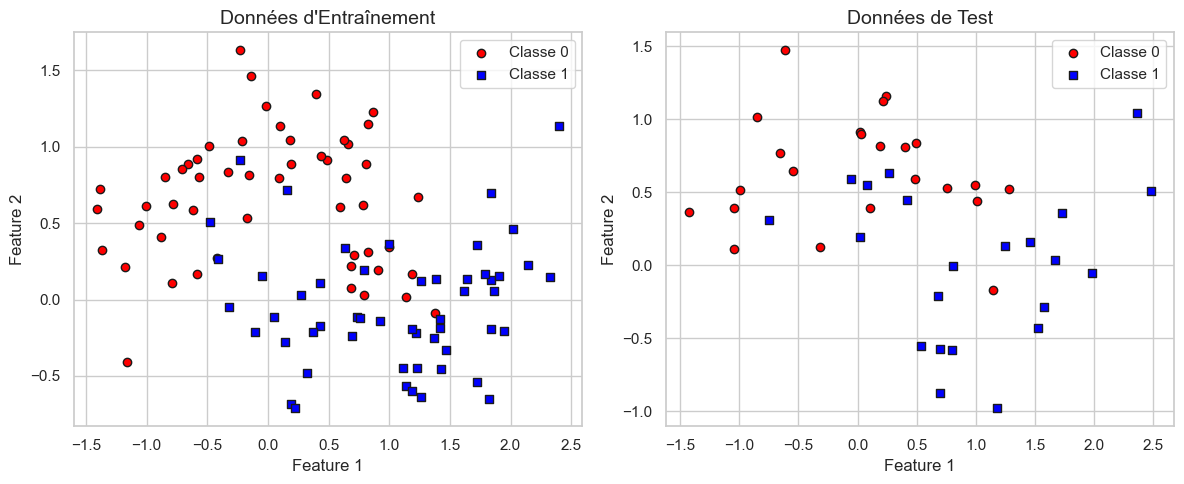

In [ ]:
# Génération des données
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)

# Séparation en ensemble d'entraînement et de test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fonction utilitaire pour afficher les données
def plot_dataset(X, y, title):
    plt.scatter(X[y==0, 0], X[y==0, 1], color='red', marker='o', edgecolors='k', label='Classe 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', marker='s', edgecolors='k', label='Classe 1')
    plt.title(title, fontsize=14)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_dataset(X_train, y_train, "Données d'Entraînement")
plt.subplot(1, 2, 2)
plot_dataset(X_test, y_test, "Données de Test")
plt.tight_layout()
plt.show()

## 2. Ingénierie des Caractéristiques (Feature Engineering)
Pour capturer la non-linéarité, nous ajoutons des caractéristiques polynomiales de degré 10. Ensuite, nous standardisons ces nouvelles caractéristiques.

In [ ]:
# Création des caractéristiques polynomiales
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print(f"Dimension des données originales : {X_train.shape}")
print(f"Dimension après transformation polynomiale : {X_train_scaled.shape}")

Dimension des données originales : (105, 2)
Dimension après transformation polynomiale : (105, 65)


## 3. Fonction de Tracé de la Frontière de Décision
Nous définissons une fonction réutilisable pour visualiser comment notre modèle sépare les classes.

In [ ]:
def plot_decision_boundary(model, X_train_data, y_train_data, X_test_data, y_test_data, title="Frontière de Décision"):
    # Création d'une grille de points
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # Transformation de la grille
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = poly.transform(grid)
    grid_scaled = scaler.transform(grid_poly)

    # Prédictions sur la grille
    Z = model.predict(grid_scaled).reshape(xx.shape)

    plt.figure(figsize=(14, 6))

    # Plot Train
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X_train_data[y_train_data==0, 0], X_train_data[y_train_data==0, 1], color='red', edgecolors='k', label='Classe 0')
    plt.scatter(X_train_data[y_train_data==1, 0], X_train_data[y_train_data==1, 1], color='blue', edgecolors='k', label='Classe 1')
    plt.title(f"{title} - Entraînement", fontsize=14)

    # Plot Test
    plt.subplot(1, 2, 2)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X_test_data[y_test_data==0, 0], X_test_data[y_test_data==0, 1], color='red', edgecolors='k', label='Classe 0')
    plt.scatter(X_test_data[y_test_data==1, 0], X_test_data[y_test_data==1, 1], color='blue', edgecolors='k', label='Classe 1')
    plt.title(f"{title} - Test", fontsize=14)

    plt.tight_layout()
    plt.show()

## 4. Modèle de Base : Sans Régularisation
Un modèle sans régularisation (`penalty=None`) avec un polynôme de degré 10 risque fortement de surapprendre (overfitting).

Précision (Train) : 0.9714
Précision (Test)  : 0.8444


c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


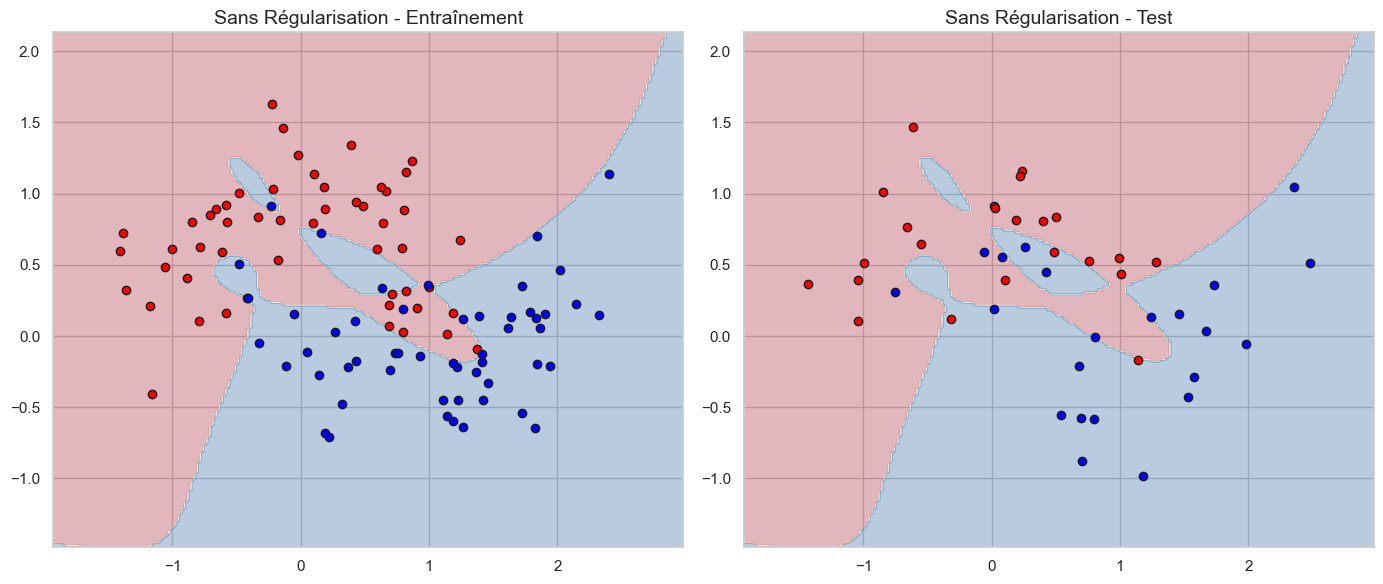

In [ ]:
# Entraînement du modèle sans régularisation
log_reg_none = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
log_reg_none.fit(X_train_scaled, y_train)

# Évaluation
train_acc_none = log_reg_none.score(X_train_scaled, y_train)
test_acc_none = log_reg_none.score(X_test_scaled, y_test)
print(f"Précision (Train) : {train_acc_none:.4f}")
print(f"Précision (Test)  : {test_acc_none:.4f}")

# Visualisation
plot_decision_boundary(log_reg_none, X_train, y_train, X_test, y_test, "Sans Régularisation")

## 5. Régularisation L1 (Lasso)
La régularisation L1 tend à annuler certains coefficients, effectuant ainsi une sélection de variables.

Précision (Train) : 0.8857
Précision (Test)  : 0.8444


c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


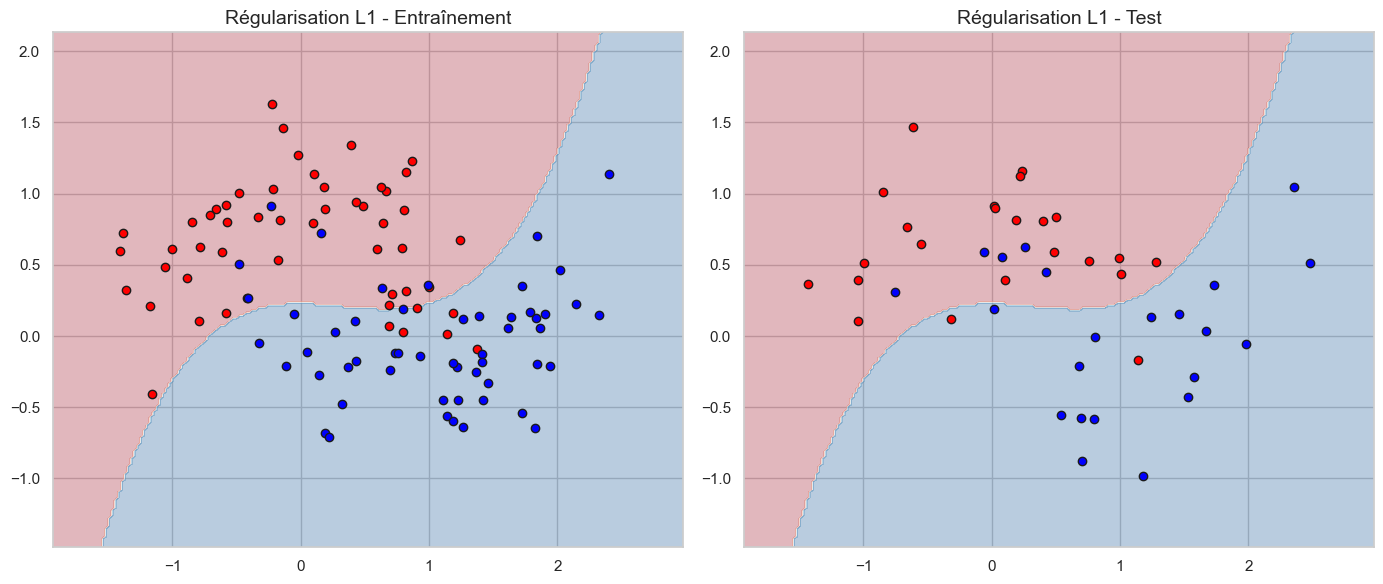

In [ ]:
# Entraînement avec régularisation L1
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000, random_state=42)
log_reg_l1.fit(X_train_scaled, y_train)

# Évaluation
train_acc_l1 = log_reg_l1.score(X_train_scaled, y_train)
test_acc_l1 = log_reg_l1.score(X_test_scaled, y_test)
print(f"Précision (Train) : {train_acc_l1:.4f}")
print(f"Précision (Test)  : {test_acc_l1:.4f}")

# Visualisation
plot_decision_boundary(log_reg_l1, X_train, y_train, X_test, y_test, "Régularisation L1")

## 6. Régularisation L2 (Ridge)
La régularisation L2 limite l'amplitude de l'ensemble des coefficients, créant ainsi une frontière de décision plus douce et généralisable.

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Précision (Train) : 0.8762
Précision (Test)  : 0.8444


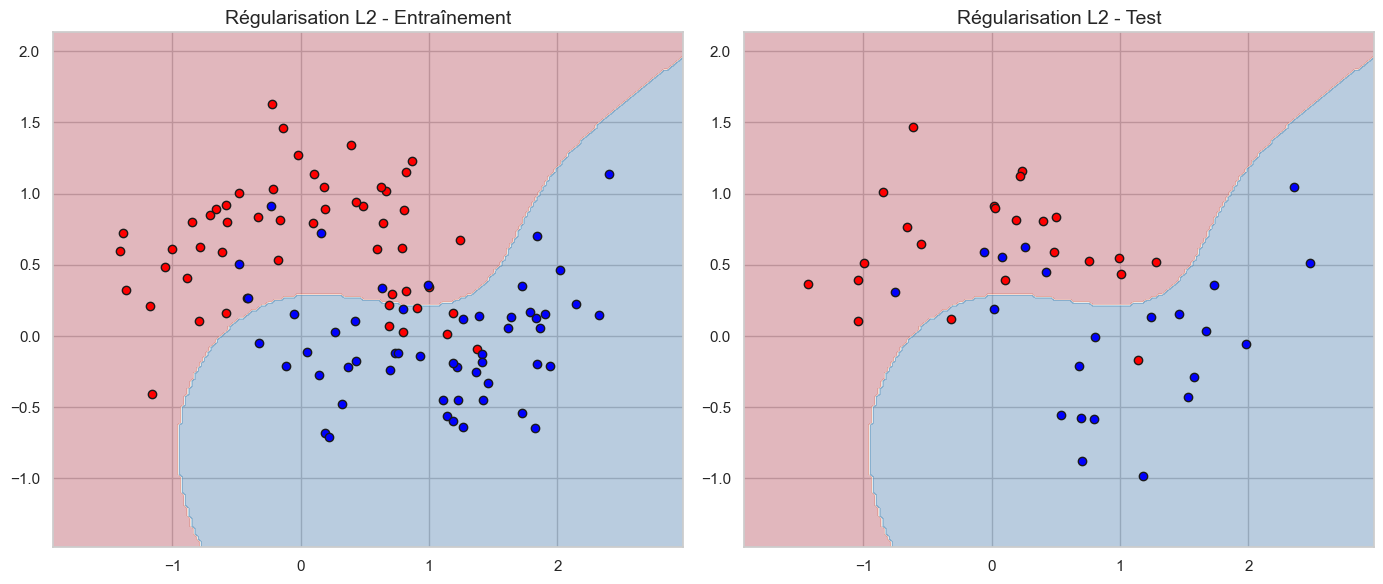

In [ ]:
# Entraînement avec régularisation L2
log_reg_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
log_reg_l2.fit(X_train_scaled, y_train)

# Évaluation
train_acc_l2 = log_reg_l2.score(X_train_scaled, y_train)
test_acc_l2 = log_reg_l2.score(X_test_scaled, y_test)
print(f"Précision (Train) : {train_acc_l2:.4f}")
print(f"Précision (Test)  : {test_acc_l2:.4f}")

# Visualisation
plot_decision_boundary(log_reg_l2, X_train, y_train, X_test, y_test, "Régularisation L2")

## 7. Synthèse des Résultats
Comparons visuellement les performances des trois approches.

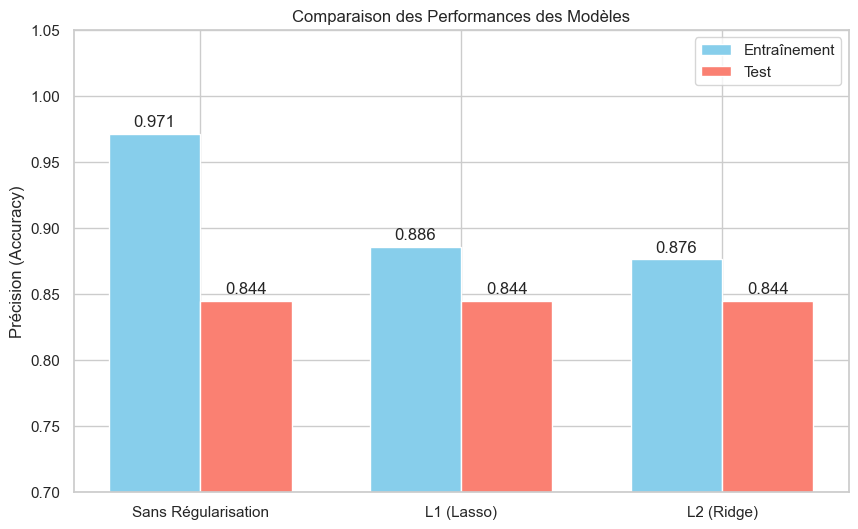

In [ ]:
# Création d'un diagramme en barres pour comparer les précisions
models = ['Sans Régularisation', 'L1 (Lasso)', 'L2 (Ridge)']
train_scores = [train_acc_none, train_acc_l1, train_acc_l2]
test_scores = [test_acc_none, test_acc_l1, test_acc_l2]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_scores, width, label='Entraînement', color='skyblue')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test', color='salmon')

ax.set_ylabel('Précision (Accuracy)')
ax.set_title('Comparaison des Performances des Modèles')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.05)
ax.legend()

# Ajout des valeurs sur les barres
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()